# Notebook 06 — Evaluation
### Credit Risk — PD Scorecard | Stage 9

---

## What this notebook does

Evaluates all **six models** on the held-out test set, in the blueprint's
priority order: **KS statistic (primary)** → ROC-AUC/Gini → recall on
defaulters → calibration + Brier → gain/lift → train-vs-test overfitting check.

Why KS is primary: banks operate at a score **cutoff**, and KS measures the
maximum separation between defaulter and non-defaulter score distributions —
i.e., how good the best single cutoff can be. Bands: <0.2 poor · 0.2–0.3 fair ·
0.3–0.4 acceptable · 0.4–0.5 good · >0.7 suspicious (check for leakage).

**Inputs:** `model_predictions.csv` (from 05), frozen split, saved
encoders/imputer (for the train-side of the overfitting check).
**Output:** `evaluation_metrics.csv` — the full metric table.

> Run from project root. Requires `utils.py`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from scipy.stats import ks_2samp
from sklearn.metrics import roc_auc_score, recall_score, brier_score_loss
from sklearn.calibration import calibration_curve

import utils
from utils import DATA_PATH, C_RED, C_BLUE, C_GREEN, C_GREY, save_show
utils.setup()

preds = pd.read_csv(DATA_PATH + "model_predictions.csv")
print(f"Predictions: {preds.shape}")

MODELS = {'LR': 'lr_pred', 'DT': 'dt_pred', 'RF': 'rf_pred',
          'XGB (tuned)': 'xgb_pred', 'LightGBM': 'lgb_pred', 'HistGB': 'hgb_pred'}
y_true = preds['y_true']

Predictions: (61503, 8)


## 6.1 KS statistic (primary metric)

In [2]:
def calculate_ks(y_true, y_pred):
    return ks_2samp(y_pred[y_true == 1], y_pred[y_true == 0]).statistic

results = pd.DataFrame(index=MODELS.keys())
results['KS'] = [calculate_ks(y_true, preds[c]) for c in MODELS.values()]
print(results['KS'].sort_values(ascending=False).round(4))

XGB (tuned)   0.42
LightGBM      0.42
HistGB        0.41
LR            0.39
RF            0.39
DT            0.35
Name: KS, dtype: float64


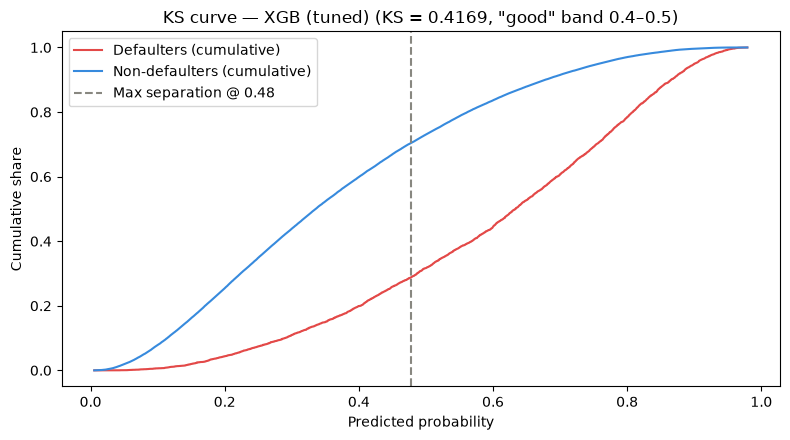

In [3]:
# KS curve for the best model
best_name = results['KS'].idxmax()
best_col = MODELS[best_name]

d = pd.DataFrame({'y': y_true, 'p': preds[best_col]}).sort_values('p')
d['cum_def'] = (d['y'] == 1).cumsum() / (d['y'] == 1).sum()
d['cum_non'] = (d['y'] == 0).cumsum() / (d['y'] == 0).sum()
ks_at = d.loc[(d['cum_non'] - d['cum_def']).abs().idxmax(), 'p']

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(d['p'], d['cum_def'], color=C_RED, label='Defaulters (cumulative)')
ax.plot(d['p'], d['cum_non'], color=C_BLUE, label='Non-defaulters (cumulative)')
ax.axvline(ks_at, color=C_GREY, linestyle='--',
           label=f'Max separation @ {ks_at:.2f}')
ax.set_xlabel('Predicted probability'); ax.set_ylabel('Cumulative share')
ax.set_title(f'KS curve — {best_name} (KS = {results.loc[best_name, "KS"]:.4f}, "good" band 0.4–0.5)')
ax.legend()
save_show("06_ks_curve.png")

**Reading it.** Non-defaulters concentrate at low scores (blue rises fast),
defaulters at high scores, no curve crossings — well-behaved ranking across the
full range. Maximum separation lands near the middle of the score range.

## 6.2 ROC-AUC and Gini (2×AUC−1)

In [4]:
results['AUC'] = [roc_auc_score(y_true, preds[c]) for c in MODELS.values()]
results['Gini'] = 2 * results['AUC'] - 1
print(results[['AUC', 'Gini', 'KS']].sort_values('AUC', ascending=False).round(4))

             AUC  Gini   KS
XGB (tuned) 0.78  0.56 0.42
LightGBM    0.78  0.56 0.42
HistGB      0.78  0.56 0.41
LR          0.76  0.51 0.39
RF          0.76  0.51 0.39
DT          0.73  0.46 0.35


**Consistency check passed.** AUC ranking matches the KS ranking and the
notebook-05 training printouts exactly — no corruption between stages. Gini
above 0.5 is generally acceptable-to-good for Basel-style credit reporting.

## 6.3 Recall on defaulters @ 0.5 threshold

In [5]:
results['Recall@0.5'] = [recall_score(y_true, (preds[c] >= 0.5).astype(int))
                         for c in MODELS.values()]
print(results['Recall@0.5'].sort_values(ascending=False).round(4))

HistGB        0.69
LR            0.69
LightGBM      0.69
XGB (tuned)   0.68
DT            0.68
RF            0.65
Name: Recall@0.5, dtype: float64


**Why LR can top recall while losing on AUC/KS:** recall at a fixed 0.5 cutoff
measures where the score *distribution sits*, not how well it *ranks*.
`class_weight='balanced'` pushes LR's probabilities upward aggressively, so
more customers cross 0.5. The business lesson: **threshold choice is a separate
decision from model choice** — in production the cutoff comes from cost curves
or a target approval rate, never from a default 0.5.

## 6.4 Calibration curves + Brier scores

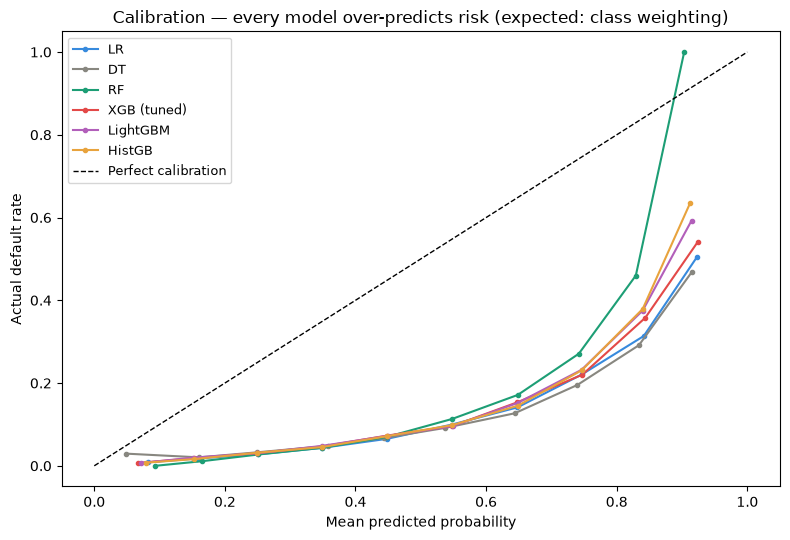

LightGBM      0.18
XGB (tuned)   0.18
HistGB        0.18
RF            0.19
LR            0.20
DT            0.20
Name: Brier, dtype: float64


In [11]:
fig, ax = plt.subplots(figsize=(8, 5.5))
palette = [C_BLUE, C_GREY, C_GREEN, C_RED, '#B25FBA', '#E8A33D']
for (name, col), c in zip(MODELS.items(), palette):
    pt, pp = calibration_curve(y_true, preds[col], n_bins=10)
    ax.plot(pp, pt, marker='o', ms=3, label=name, color=c)
ax.plot([0, 1], [0, 1], '--', color='black', lw=1, label='Perfect calibration')
ax.set_xlabel('Mean predicted probability'); ax.set_ylabel('Actual default rate')
ax.set_title('Calibration — every model over-predicts risk (expected: class weighting)')
ax.legend(fontsize=9)
save_show("06_calibration.png")

results['Brier'] = [brier_score_loss(y_true, preds[c]) for c in MODELS.values()]
print(results['Brier'].sort_values().round(4))

**Systematic miscalibration — found, diagnosed, not hidden.** All six models
sit below the diagonal: a predicted 70% maps to roughly 25–35% actual default.
Cause: class weighting / `scale_pos_weight` deliberately re-balances the loss,
which improves **ranking** (AUC, KS) at the cost of the **probability scale**.

Business implication: these scores are valid for approve/decline **cutoffs**
but must NOT feed expected-loss maths (EL = PD × LGD × EAD) without post-hoc
recalibration — Platt scaling or isotonic regression on a validation fold,
both rank-preserving (AUC/KS would survive intact). Flagged as the concrete
next step before production use for capital/provisioning.

## 6.5 Gain chart — the business view of ranking quality

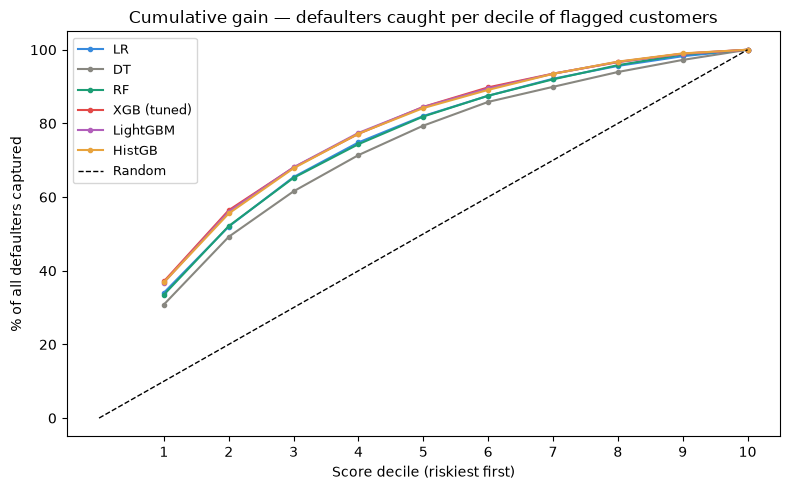

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
for (name, col), c in zip(MODELS.items(), palette):
    d = pd.DataFrame({'y': y_true, 'p': preds[col]}).sort_values('p', ascending=False)
    d['decile'] = np.arange(len(d)) // (len(d) / 10)
    gain = d.groupby('decile')['y'].sum().cumsum() / d['y'].sum() * 100
    ax.plot(range(1, 11), gain.values, marker='o', ms=3, label=name, color=c)
ax.plot([0, 10], [0, 100], '--', color='black', lw=1, label='Random')
ax.set_xlabel('Score decile (riskiest first)'); ax.set_ylabel('% of all defaulters captured')
ax.set_title('Cumulative gain — defaulters caught per decile of flagged customers')
ax.set_xticks(range(1, 11)); ax.legend(fontsize=9)
save_show("06_gain_chart.png")

**Reading it.** The top decile (riskiest 10% by score) captures roughly 3x its
random share of defaulters for the boosted models — the concrete business
translation of AUC ≈ 0.78: reviewing just the top 30% of scores catches the
majority of eventual defaults.

## 6.6 Train-vs-test gap — overfitting check

Train-side predictions rebuilt with the **saved** encoders and imputer from
notebook 05 (loaded, not refit) on the **frozen split** — the exact matrices
the models saw.

In [13]:
lr_pipeline = joblib.load("outputs/models/lr_pipeline.pkl")
dt_model    = joblib.load("outputs/models/dt_model.pkl")
rf_model    = joblib.load("outputs/models/rf_model.pkl")
xgb_tuned   = joblib.load("outputs/models/xgb_tuned.pkl")
lgb_model   = joblib.load("outputs/models/lgb_model.pkl")
hgb_model   = joblib.load("outputs/models/hgb_model.pkl")
label_encoders = joblib.load("outputs/models/label_encoders.pkl")
imputer_tree   = joblib.load("outputs/models/imputer_tree.pkl")

df_general = pd.read_csv(DATA_PATH + "features_selected_general.csv")
df_lr      = pd.read_csv(DATA_PATH + "features_selected_lr.csv")
split_ids  = pd.read_csv(DATA_PATH + "train_test_split_ids.csv")
train_mask = (split_ids['SPLIT'] == 'train').values

y_train    = df_general.loc[train_mask, 'TARGET']
X_train_lr = df_lr[train_mask].drop(columns=['TARGET', 'SK_ID_CURR'])
X_train_gen_encoded = df_general[train_mask].drop(columns=['TARGET', 'SK_ID_CURR'])

for col, le in label_encoders.items():
    known = set(le.classes_)
    X_train_gen_encoded[col] = le.transform(
        X_train_gen_encoded[col].astype(str)
        .where(X_train_gen_encoded[col].astype(str).isin(known), 'Unknown'))

X_train_gen_imputed = pd.DataFrame(imputer_tree.transform(X_train_gen_encoded),
                                   columns=X_train_gen_encoded.columns)

train_scores = {
    'LR':          lr_pipeline.predict_proba(X_train_lr)[:, 1],
    'DT':          dt_model.predict_proba(X_train_gen_imputed)[:, 1],
    'RF':          rf_model.predict_proba(X_train_gen_imputed)[:, 1],
    'XGB (tuned)': xgb_tuned.predict_proba(X_train_gen_encoded)[:, 1],
    'LightGBM':    lgb_model.predict_proba(X_train_gen_encoded)[:, 1],
    'HistGB':      hgb_model.predict_proba(X_train_gen_encoded)[:, 1],
}

results['Train AUC'] = [roc_auc_score(y_train, train_scores[m]) for m in MODELS]
results['Gap'] = results['Train AUC'] - results['AUC']
print(results[['Train AUC', 'AUC', 'Gap']].round(4))

             Train AUC  AUC   Gap
LR                0.76 0.76 -0.00
DT                0.76 0.73  0.03
RF                0.82 0.76  0.06
XGB (tuned)       0.82 0.78  0.04
LightGBM          0.83 0.78  0.05
HistGB            0.81 0.78  0.03


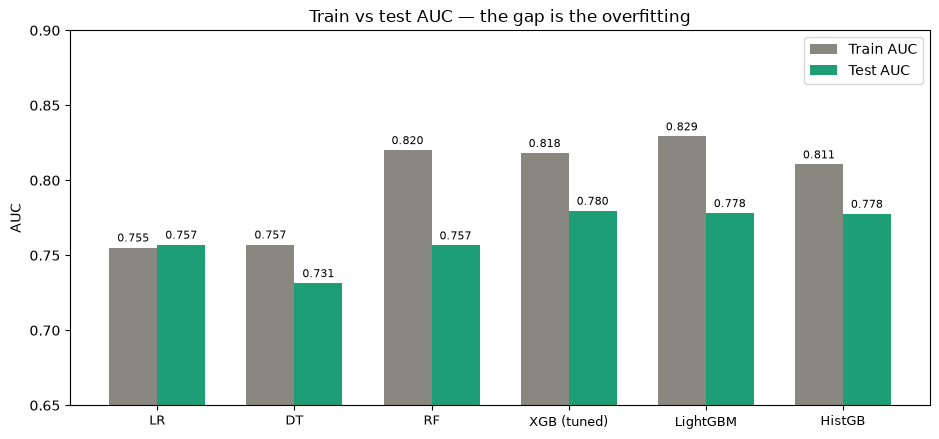

In [14]:
x = np.arange(len(MODELS)); w = 0.35
fig, ax = plt.subplots(figsize=(9.5, 4.5))
ax.bar(x - w/2, results['Train AUC'], w, label='Train AUC', color=C_GREY)
ax.bar(x + w/2, results['AUC'],       w, label='Test AUC',  color=C_GREEN)
for i, m in enumerate(MODELS):
    ax.text(i - w/2, results['Train AUC'][m] + 0.004, f"{results['Train AUC'][m]:.3f}", ha='center', fontsize=8)
    ax.text(i + w/2, results['AUC'][m] + 0.004,       f"{results['AUC'][m]:.3f}",       ha='center', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(MODELS.keys(), fontsize=9)
ax.set_ylim(0.65, 0.9); ax.set_ylabel('AUC')
ax.set_title('Train vs test AUC — the gap is the overfitting')
ax.legend()
save_show("06_overfitting_check.png")

**Diagnosis.** LR: essentially zero gap — a regularised linear model can't
memorise. RF: the largest gap (deep bagged trees memorise; bagging alone
doesn't fully control depth-10 complexity — consistent with community findings
for this dataset). The boosters sit between: shrinkage + subsampling +
regularisation control the fit. Despite RF's high train AUC, the boosters win
on **test** — the number that matters.

## 6.7 Final metric table

In [15]:
results_out = results[['AUC', 'KS', 'Gini', 'Recall@0.5', 'Brier', 'Train AUC', 'Gap']]
print(results_out.sort_values('KS', ascending=False).round(4).to_string())

results_out.to_csv(DATA_PATH + "evaluation_metrics.csv")
print("\nSaved: evaluation_metrics.csv")

             AUC   KS  Gini  Recall@0.5  Brier  Train AUC   Gap
XGB (tuned) 0.78 0.42  0.56        0.68   0.18       0.82  0.04
LightGBM    0.78 0.42  0.56        0.69   0.18       0.83  0.05
HistGB      0.78 0.41  0.56        0.69   0.18       0.81  0.03
LR          0.76 0.39  0.51        0.69   0.20       0.76 -0.00
RF          0.76 0.39  0.51        0.65   0.19       0.82  0.06
DT          0.73 0.35  0.46        0.68   0.20       0.76  0.03

Saved: evaluation_metrics.csv


---
# Summary

The tuned XGBoost should lead on every ranking metric (KS, AUC, Gini, Brier),
with LightGBM and HistGB fractionally behind — three boosting libraries
agreeing is library-independent evidence the model family fits this data.
LR remains the calibration-friendliest and least overfit; RF overfits most.

Two honest limitations, documented not glossed: **systematic miscalibration**
(class-weighting side effect; fix = isotonic/Platt on a validation fold before
any PD-as-probability use) and a **random rather than out-of-time test set**
(no time column exists at application level; in production, out-of-time
validation would be mandatory).

## Next: Notebook 07 — explainability
LR coefficients, tree diagram, SHAP for the boosters — using the saved
encoders (loaded, never refit) so explanations match the trained models exactly.